# 05 - Quantify latent complexity for matched normal–tumor comparisons

This notebook quantifies within-group latent geometry for matched normal–tumor comparisons.

It performs five tasks:

1. Loads latent coordinates generated by the trained VAE
2. Loads aligned metadata from the preprocessing pipeline
3. Constructs a comparison-ready working table using standardized labels
4. Computes latent geometry metrics separately for each normal and tumor group
5. Saves derived tables and summary plots for downstream reporting

The unit of analysis in this notebook is the matched comparison, such as `BLAD/TCC` or `Brain/GBM`, not the individual cancer label alone.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)


In [25]:
NOTEBOOK_DIR = Path.cwd()
LATENT_PROJECT_DIR = NOTEBOOK_DIR.parent
INPUT_DIR = LATENT_PROJECT_DIR / "data" / "inputs"
PROCESSED_DIR = LATENT_PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = LATENT_PROJECT_DIR / "output"
TABLES_DIR = OUTPUT_DIR / "tables"
LATENT_TABLES_DIR = TABLES_DIR / "latent"
PLOTS_DIR = OUTPUT_DIR / "plots"
LATENT_PLOTS_DIR = PLOTS_DIR / "latent"

LATENT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
LATENT_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

latent_path = PROCESSED_DIR / "latent.npy"
metadata_path = INPUT_DIR / "hu35ksuba_metadata.csv"

if not latent_path.exists():
    raise FileNotFoundError(f"Missing latent file: {latent_path}")
if not metadata_path.exists():
    raise FileNotFoundError(f"Missing metadata file: {metadata_path}")

latent = np.load(latent_path)
metadata = pd.read_csv(metadata_path, index_col=0)

required_cols = [
    "sample_id",
    "geo_accession",
    "title",
    "platform_id",
    "disease_clean",
    "tissue_clean",
    "condition",
    "tissue_label",
]
missing = [c for c in required_cols if c not in metadata.columns]
if missing:
    raise KeyError(f"Missing required metadata columns: {missing}")

if latent.shape[0] != metadata.shape[0]:
    raise ValueError(
        f"Row mismatch: latent has {latent.shape[0]} rows but metadata has {metadata.shape[0]} rows."
    )

latent_df = pd.DataFrame(latent, index=metadata.index)
latent_df.columns = [f"z{i+1}" for i in range(latent_df.shape[1])]

df = latent_df.join(metadata)

print("latent shape  :", latent.shape)
print("metadata shape:", metadata.shape)
print("df shape      :", df.shape)

latent shape  : (278, 10)
metadata shape: (278, 8)
df shape      : (278, 18)


In [26]:
# ------------------------------------------------------------------
# Tissue-specific normal/tumor comparisons using canonical labels
# ------------------------------------------------------------------
comparison_map = {
    "BLAD/TCC": ("Bladder", "bladder transitional cell carcinoma"),
    "BR/BRAD": ("Breast", "breast adenocarcinoma"),
    "COL/COADREAD": ("Colon", "colorectal adenocarcinoma"),
    "KID/RCC": ("Kidney", "renal cell carcinoma"),
    "LU/LUAD": ("Lung", "lung adenocarcinoma"),
    "OV/OVAD": ("Ovary", "ovarian adenocarcinoma"),
    "PA/PAAD": ("Pancreas", "pancreatic adenocarcinoma"),
    "PR/PRAD": ("Prostate", "prostate adenocarcinoma"),
    "UT/EAC": ("Uterus", "uterine adenocarcinoma"),
    "Brain/GBM": ("Brain", "glioblastoma"),
    "Brain/MB": ("Brain", "medulloblastoma"),
    "GC/FL": ("Lymphoid Tissue", "Follicular lymphoma"),
    "GC/LBCL": ("Lymphoid Tissue", "large B-cell lymphoma"),
    "PB/AML": ("Blood", "acute myeloid leukemia"),
    "PB/B-ALL": ("Bone Marrow", "B-cell ALL"),
    "PB/T-ALL": ("Bone Marrow", "T-cell ALL"),
}

latent_cols = [c for c in df.columns if c.startswith("z")]

work = df.copy()
work["tissue"] = work["tissue_clean"].astype(str).str.strip()
work["disease"] = work["disease_clean"].astype(str).str.strip()
work["state"] = work["condition"].astype(str).str.strip()

# Assign canonical paired comparison labels to tumor samples
work["short_label"] = pd.NA
for comp, (normal_tissue, tumor_disease) in comparison_map.items():
    tumor_mask = (
        (work["state"] == "cancer") &
        (work["tissue"] == normal_tissue) &
        (work["disease"] == tumor_disease)
    )
    work.loc[tumor_mask, "short_label"] = comp

# Assign the same paired labels to matched normal samples
for comp, (normal_tissue, tumor_disease) in comparison_map.items():
    normal_mask = (
        (work["state"] == "normal") &
        (work["tissue"] == normal_tissue)
    )
    work.loc[normal_mask, "short_label"] = comp

latent_with_meta = work[
    [
        "sample_id",
        "geo_accession",
        "title",
        "platform_id",
        "tissue",
        "disease",
        "state",
        "short_label",
        "tissue_label",
    ] + latent_cols
].copy()

print("latent_with_meta shape:", latent_with_meta.shape)
print("Matched comparison labels:", latent_with_meta["short_label"].dropna().nunique())
print("Unlabeled rows:", latent_with_meta["short_label"].isna().sum())

latent_with_meta shape: (278, 19)
Matched comparison labels: 16
Unlabeled rows: 30


In [27]:
# ------------------------------------------------------------------
# Metric helpers
# ------------------------------------------------------------------
def safe_cov(X: np.ndarray) -> np.ndarray:
    if X.ndim != 2:
        raise ValueError("X must be 2-dimensional.")
    if X.shape[0] < 2:
        return np.full((X.shape[1], X.shape[1]), np.nan)
    return np.cov(X, rowvar=False)

def eigvals_sorted(cov: np.ndarray) -> np.ndarray:
    if np.isnan(cov).all():
        return np.array([np.nan])
    vals = np.linalg.eigvalsh(cov)
    vals = np.clip(vals, 0, None)
    return np.sort(vals)[::-1]

def participation_ratio(eigs: np.ndarray) -> float:
    if np.isnan(eigs).all():
        return np.nan
    s1 = np.sum(eigs)
    s2 = np.sum(eigs**2)
    if s2 <= 0:
        return np.nan
    return float((s1**2) / s2)

def eig_entropy(eigs: np.ndarray) -> float:
    if np.isnan(eigs).all():
        return np.nan
    total = np.sum(eigs)
    if total <= 0:
        return np.nan
    p = eigs / total
    p = p[p > 0]
    if len(p) == 0:
        return np.nan
    return float(-(p * np.log(p)).sum())

def top_eig_fraction(eigs: np.ndarray) -> float:
    if np.isnan(eigs).all():
        return np.nan
    total = np.sum(eigs)
    if total <= 0:
        return np.nan
    return float(eigs[0] / total)

def centroid_distances(X: np.ndarray) -> np.ndarray:
    if X.ndim != 2:
        raise ValueError("X must be 2-dimensional.")
    if X.shape[0] == 0:
        return np.array([np.nan])
    c = X.mean(axis=0)
    return np.linalg.norm(X - c, axis=1)


In [28]:
# ------------------------------------------------------------------
# Compute one row per matched comparison
# ------------------------------------------------------------------
results = []

for comp, (normal_tissue, tumor_disease) in comparison_map.items():
    df_normal = work.loc[
        (work["state"] == "normal") &
        (work["tissue"] == normal_tissue)
    ]
    df_tumor = work.loc[
        (work["state"] == "cancer") &
        (work["tissue"] == normal_tissue) &
        (work["disease"] == tumor_disease)
    ]

    n_normal = len(df_normal)
    n_tumor = len(df_tumor)

    if n_normal < 2 or n_tumor < 2:
        print(f"Skipping {comp}: n_normal={n_normal}, n_tumor={n_tumor}")
        continue

    X_normal = df_normal[latent_cols].to_numpy(dtype=float)
    X_tumor = df_tumor[latent_cols].to_numpy(dtype=float)

    cov_normal = safe_cov(X_normal)
    cov_tumor = safe_cov(X_tumor)

    eigs_normal = eigvals_sorted(cov_normal)
    eigs_tumor = eigvals_sorted(cov_tumor)

    pr_normal = participation_ratio(eigs_normal)
    pr_tumor = participation_ratio(eigs_tumor)

    ent_normal = eig_entropy(eigs_normal)
    ent_tumor = eig_entropy(eigs_tumor)

    anisotropy_normal = top_eig_fraction(eigs_normal)
    anisotropy_tumor = top_eig_fraction(eigs_tumor)

    radius_normal = float(np.nanmean(centroid_distances(X_normal)))
    radius_tumor = float(np.nanmean(centroid_distances(X_tumor)))

    centroid_normal = X_normal.mean(axis=0)
    centroid_tumor = X_tumor.mean(axis=0)
    centroid_distance = float(np.linalg.norm(centroid_tumor - centroid_normal))

    results.append(
        {
            "comparison": comp,
            "normal_tissue": normal_tissue,
            "tumor_disease": tumor_disease,
            "n_normal": n_normal,
            "n_tumor": n_tumor,
            "pr_normal": pr_normal,
            "pr_tumor": pr_tumor,
            "pr_delta": pr_tumor - pr_normal,
            "eig_entropy_normal": ent_normal,
            "eig_entropy_tumor": ent_tumor,
            "eig_entropy_delta": ent_tumor - ent_normal,
            "anisotropy_normal": anisotropy_normal,
            "anisotropy_tumor": anisotropy_tumor,
            "anisotropy_delta": anisotropy_tumor - anisotropy_normal,
            "radius_normal": radius_normal,
            "radius_tumor": radius_tumor,
            "radius_delta": radius_tumor - radius_normal,
            "centroid_distance": centroid_distance,
        }
    )

latent_comparison_df = (
    pd.DataFrame(results)
    .sort_values("comparison")
    .reset_index(drop=True)
)

latent_comparison_df["normal_code"] = latent_comparison_df["comparison"].str.split("/").str[0]
latent_comparison_df["tumor_code"] = latent_comparison_df["comparison"].str.split("/").str[1]

print("latent_comparison_df shape:", latent_comparison_df.shape)
display(latent_comparison_df)

Skipping PB/AML: n_normal=5, n_tumor=0
Skipping PB/B-ALL: n_normal=0, n_tumor=10
Skipping PB/T-ALL: n_normal=0, n_tumor=10
latent_comparison_df shape: (13, 20)


,comparison,normal_tissue,tumor_disease,n_normal,n_tumor,pr_normal,pr_tumor,pr_delta,eig_entropy_normal,eig_entropy_tumor,eig_entropy_delta,anisotropy_normal,anisotropy_tumor,anisotropy_delta,radius_normal,radius_tumor,radius_delta,centroid_distance,normal_code,tumor_code
0,BLAD/TCC,Bladder,bladder transitional cell carcinoma,7,11,2.868039,3.416281,0.548242,1.210105,1.430003,0.219898,0.485303,0.415730,-0.069573,20.936583,20.135148,-0.801435,37.079935,BLAD,TCC
1,BR/BRAD,Breast,breast adenocarcinoma,5,11,1.653903,2.879065,1.225162,0.654532,1.318833,0.664301,0.740404,0.511646,-0.228758,25.817442,30.178578,4.361136,35.517579,BR,BRAD
2,Brain/GBM,Brain,glioblastoma,8,10,2.591654,3.901760,1.310106,1.140887,1.578678,0.437790,0.539627,0.375599,-0.164028,17.914772,22.012531,4.097759,26.573303,Brain,GBM
3,Brain/MB,Brain,medulloblastoma,8,10,2.591654,3.435262,0.843608,1.140887,1.428463,0.287576,0.539627,0.403017,-0.136610,17.914772,19.155003,1.240231,33.630825,Brain,MB
4,COL/COADREAD,Colon,colorectal adenocarcinoma,11,11,2.534254,2.814696,0.280442,1.151971,1.352936,0.200965,0.546291,0.540648,-0.005643,19.358334,27.708412,8.350078,25.237612,COL,COADREAD
5,GC/FL,Lymphoid Tissue,Follicular lymphoma,6,11,1.385258,3.772358,2.387100,0.553617,1.536914,0.983298,0.840209,0.401848,-0.438362,17.687778,17.191157,-0.496621,28.670954,GC,FL
6,GC/LBCL,Lymphoid Tissue,large B-cell lymphoma,6,11,1.385258,3.276065,1.890807,0.553617,1.463910,0.910293,0.840209,0.481679,-0.358530,17.687778,12.686540,-5.001238,26.277790,GC,LBCL
7,KID/RCC,Kidney,renal cell carcinoma,12,11,3.347660,3.133412,-0.214248,1.421542,1.356495,-0.065047,0.406812,0.450173,0.043361,16.744116,27.882033,11.137916,17.164091,KID,RCC
8,LU/LUAD,Lung,lung adenocarcinoma,7,11,1.931388,2.761039,0.829652,0.883787,1.319109,0.435322,0.677208,0.544148,-0.133060,21.418060,25.736663,4.318603,15.243725,LU,LUAD
9,OV/OVAD,Ovary,ovarian adenocarcinoma,4,11,2.162428,2.431250,0.268821,0.905705,1.199133,0.293428,0.614311,0.580747,-0.033564,14.984917,25.331491,10.346574,25.847101,OV,OVAD


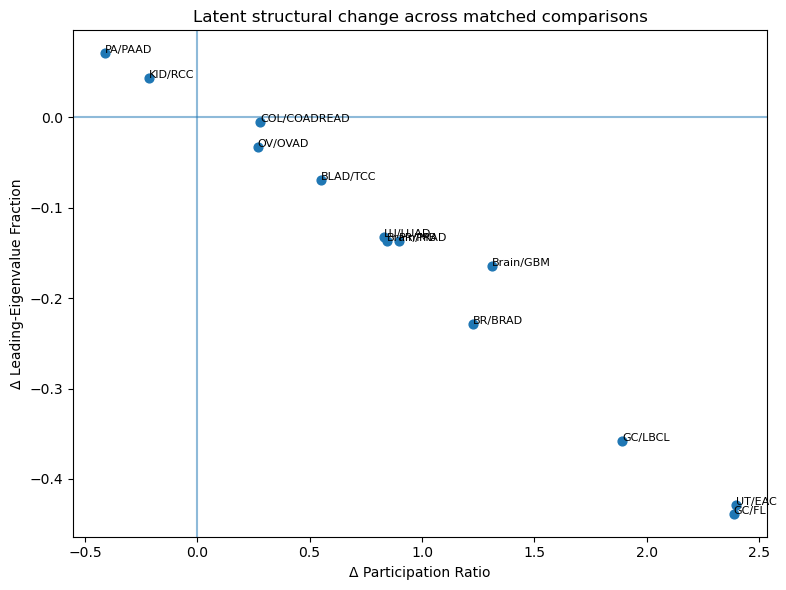

In [29]:
# ------------------------------------------------------------------
# Quick structural-change plot
# ------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.axhline(0, alpha=0.5)
plt.axvline(0, alpha=0.5)

x = latent_comparison_df["pr_delta"]
y = latent_comparison_df["anisotropy_delta"]
labels = latent_comparison_df["comparison"]

plt.scatter(x, y, s=40)

for xi, yi, lab in zip(x, y, labels):
    plt.text(xi, yi, lab, fontsize=8)

plt.xlabel("Δ Participation Ratio")
plt.ylabel("Δ Leading-Eigenvalue Fraction")
plt.title("Latent structural change across matched comparisons")
plt.tight_layout()

plt.savefig(
    LATENT_PLOTS_DIR / "latent_structural_change_space.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# ------------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------------
latent_with_meta.to_csv(LATENT_TABLES_DIR / "latent_with_metadata.csv", index=False)
latent_comparison_df.to_csv(LATENT_TABLES_DIR / "latent_comparison_metrics.csv", index=False)

print("Saved:")
print(" -", LATENT_TABLES_DIR / "latent_with_metadata.csv")
print(" -", LATENT_TABLES_DIR / "latent_comparison_metrics.csv")


Saved:
 - C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\projects\cancer-latent-space\output\tables\latent\latent_with_metadata.csv
 - C:\Users\drziy\OneDrive\Desktop\Ali\scientific_research_current\global-cancer-complexity\projects\cancer-latent-space\output\tables\latent\latent_comparison_metrics.csv
